In [17]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [18]:
np.random.seed(1)

#### Simulating Spike Count Data for LNP Model

In [20]:
# True neural parameters.

true_intercept = 1.0
true_slope = 0.8

# Simulating stimuli.

n_trials = 200

stimulus = np.linspace(
    0,
    5,
    n_trials
)

# Computing the expected firing rate.

true_rate = np.exp(
    true_intercept +
    true_slope * stimulus
)

# Simulating spike counts.

spike_counts = np.random.poisson(
    true_rate
)

# Displaying information.

print("True intercept:", true_intercept)

print("True slope:", true_slope)

print("Number of trials:", n_trials)

print("Average spike count:", round(np.mean(spike_counts), 2))

True intercept: 1.0
True slope: 0.8
Number of trials: 200
Average spike count: 37.24


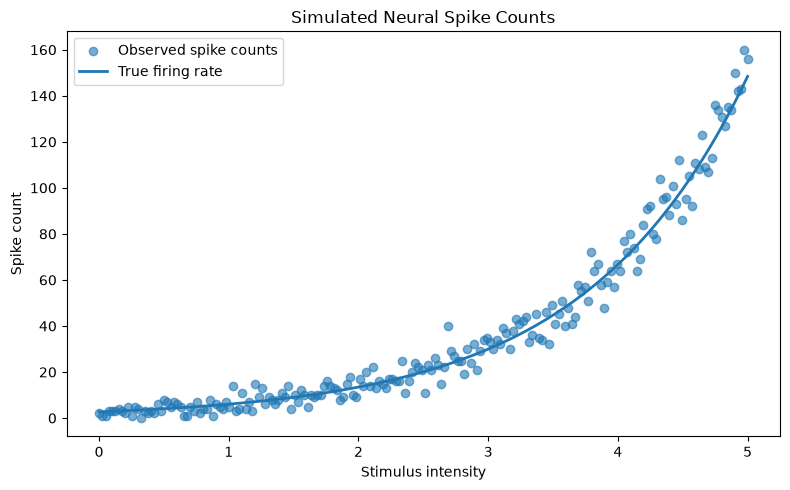

In [21]:
# Visualizing the simulated neuron.

plt.figure(figsize=(8,5))

plt.scatter(
    stimulus,
    spike_counts,
    alpha=0.6,
    label="Observed spike counts"
)

plt.plot(
    stimulus,
    true_rate,
    linewidth=2,
    label="True firing rate"
)

plt.title("Simulated Neural Spike Counts")
plt.xlabel("Stimulus intensity")
plt.ylabel("Spike count")

plt.legend()

plt.tight_layout()

plt.show()

#### Bayesian LNP Model

In [22]:
# Building the Bayesian LNP model.

with pm.Model() as lnp_model:

    # Prior distributions.
    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=3
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=3
    )

    # Linear stage.
    linear_prediction = (
        intercept +
        slope * stimulus
    )

    # Nonlinear stage.
    firing_rate = pm.Deterministic(
        "firing_rate",
        pm.math.exp(linear_prediction)
    )

    # Poisson stage.
    spike_observations = pm.Poisson(
        "spike_counts",
        mu=firing_rate,
        observed=spike_counts
    )

    # Posterior sampling.
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


In [23]:
# Posterior Summary

summary = az.summary(
    trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

print(summary)

            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept  1.010  0.044     0.923      1.097      0.001    0.001    1782.0   
slope      0.802  0.011     0.779      0.823      0.000    0.000    1797.0   

           ess_tail  r_hat  
intercept    1720.0    1.0  
slope        1695.0    1.0  


In [24]:
# Comparing Estimated and True Parameters.

print("True Parameters")
print(f"Intercept : {true_intercept}")
print(f"Slope     : {true_slope}")

posterior = az.summary(
    trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

print("\nPosterior Estimates\n")

for parameter, true_value in zip(
    ["intercept", "slope"],
    [true_intercept, true_slope]
):

    mean = posterior.loc[parameter, "mean"]
    lower = posterior.loc[parameter, "hdi_2.5%"]
    upper = posterior.loc[parameter, "hdi_97.5%"]

    print(parameter)
    print(f"Posterior mean : {mean:.3f}")
    print(f"95% HDI        : [{lower:.3f}, {upper:.3f}]")
    print(f"True value     : {true_value}")
    print()

True Parameters
Intercept : 1.0
Slope     : 0.8

Posterior Estimates

intercept
Posterior mean : 1.010
95% HDI        : [0.923, 1.097]
True value     : 1.0

slope
Posterior mean : 0.802
95% HDI        : [0.779, 0.823]
True value     : 0.8



#### Interpret Neural Parameters with Uncertainty

In [25]:
# Extracting posterior summary.

summary = az.summary(
    trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

# Posterior statistics.

intercept_mean = summary.loc["intercept", "mean"]
intercept_lower = summary.loc["intercept", "hdi_2.5%"]
intercept_upper = summary.loc["intercept", "hdi_97.5%"]

slope_mean = summary.loc["slope", "mean"]
slope_lower = summary.loc["slope", "hdi_2.5%"]
slope_upper = summary.loc["slope", "hdi_97.5%"]

# Converting the intercept to baseline firing rate.

baseline_rate = np.exp(intercept_mean)

# Displaying results.

print("Posterior Summary\n")

print(f"Intercept : {intercept_mean:.3f}")
print(f"95% HDI   : [{intercept_lower:.3f}, {intercept_upper:.3f}]")

print(f"Slope     : {slope_mean:.3f}")
print(f"95% HDI   : [{slope_lower:.3f}, {slope_upper:.3f}]")

print(f"Estimated baseline firing rate: {baseline_rate:.2f} spikes")

print("\nTrue Parameters\n")

print(f"Intercept : {true_intercept}")
print(f"Slope     : {true_slope}")

Posterior Summary

Intercept : 1.010
95% HDI   : [0.923, 1.097]
Slope     : 0.802
95% HDI   : [0.779, 0.823]
Estimated baseline firing rate: 2.75 spikes

True Parameters

Intercept : 1.0
Slope     : 0.8


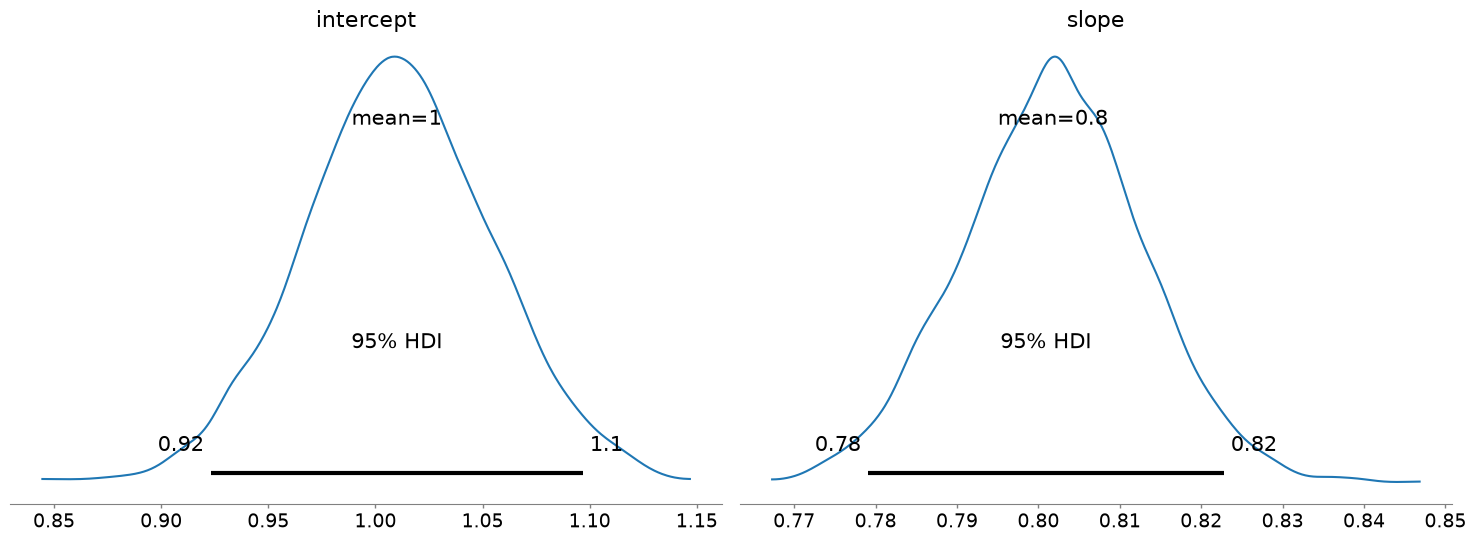

In [26]:
# Posterior Visualization

az.plot_posterior(
    trace,
    var_names=["intercept", "slope"],
    hdi_prob=0.95
)

plt.tight_layout()

plt.show()